# Validate different scenarios against each other - Regional

In [78]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import geometry
import matplotlib.pyplot as plt
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
import contextily as cx
from quetzal.model import stepmodel
from quetzal.io import excel
from syspy.skims import skims

## Scenario settings

In [79]:
# Choose scenarios
scenario_ref = 'reference'
scenarios = [scenario_ref] + ['Reactivation', 'Shift', 'Reactivation+Shift']

In [80]:
input_path = '../input/'
network_path = '../input_static/'
output_path = '../output/'
model_path = '../model/'
params = excel.read_var(file='../input/parameters.xls', scenario=scenario_ref)
segments = [s.strip() for s in params['general']['demand_segments'].split(';')]
purposes = [s.split('_')[0] for s in segments][::2]

In [81]:
# Load model zones
ref = stepmodel.read_json(model_path + scenario_ref + '/de_zones')
ref.zones = gpd.GeoDataFrame(ref.zones, crs=ref.epsg)

In [82]:
# Choose region
# DE115 and DE149 are interesting for rail reactivation
#region_name = 'Sigmaringen_region'
region_name = 'Stuttgart_region'
zone_ids = list(ref.zones.loc[ref.zones['NUTS_ID']=='DE115', 'FID']) + [81150052, 81255012, 81255005] # Stuttgart surrounding
#zone_ids = list(ref.zones.loc[(ref.zones['NUTS_ID']=='DE149') & (ref.zones['FID']!=84375001), 'FID']) + [83355006, 84365001]
polygon = ref.zones.loc[zone_ids, 'geometry'].union_all()
# Get region boundary coords
xx,yy = polygon.envelope.exterior.coords.xy
x0 = xx[0]
x1 = xx[1]
y0 = yy[0]
y1 = yy[2]

In [83]:
# All regions near reactivated railway line
all_zone_ids = [int(i) for i in '10010000;10020000;10040000;10510011;10530032;10530100;10535323;10535358;10545489;10550028;10560048;10560049;10565690;10570001;10570008;10570091;10575727;10575755;10575782;10575785;10580034;10580135;10585833;10590183;10595952;10605005;10610113;10615138;10615179;10615189;20000000;31010000;31020000;31510040;31515402;31515406;31540019;31540028;31550003;31550013;31570008;32520001;32520005;32555408;32555409;32559502;32570028;32570031;32570035;32575401;32575404;32575405;33510004;33510006;33510026;33530040;33535401;33535402;33535405;33535406;33545406;33550001;33550009;33550022;33555401;33555405;33555406;33555407;33560007;33560011;33570008;33570016;33570039;33575403;33575404;33575405;33575406;33575408;33580002;33580024;33590038;33595402;33595406;33610003;33610005;33610012;34040000;34520001;34520019;34520023;34520027;34525403;34560001;34560015;34565401;34565402;34590004;34590005;34610007;34625401;40120000;51120000;51140000;51160000;51190000;51200000;51240000;51540024;51540036;51540040;51540048;51540056;51580012;51580028;51580032;51580036;51620016;51620020;51620024;51660036;51700008;51700024;51700028;51700032;51700044;51700048;51700052;53140000;53150000;53340002;53340004;53340008;53340012;53340032;53340036;53580004;53580024;53580036;53620004;53620016;53620040;53660020;53660024;53660036;53700020;53700036;53700040;53740004;53740008;53740012;53740016;53740024;53740028;53740032;53740040;53740044;53740048;53740052;53780004;53780024;53780032;53820012;53820028;53820044;53820056;53820060;53820068;55150000;55540008;55540012;55540016;55540020;55540048;55540064;55580012;55580040;55660016;55660028;55660040;55660044;55660048;55660056;55660060;55660076;55660084;55660088;55660092;55700004;55700008;55700020;55700040;55700048;57540008;57540016;57540044;57540048;57660012;57660024;57660044;57740012;57740016;57740024;57740032;57740036;59540008;59540012;59540016;59540024;59540028;59580004;59580012;59580044;59620016;59620040;59660008;59660024;59740004;59740016;59740028;59740044;64110000;64120000;64140000;64320004;64320008;64320009;64320011;64320019;64320020;64320023;64330011;64340004;64350001;64350027;64350029;64359200;64380009;64390001;64390002;64390006;64390015;64400024;65310001;65310008;65310010;65310013;65310015;65310017;65310018;65320003;65320005;65320006;65320009;65320018;65320021;65320022;65330008;65330017;65330018;65340001;65340003;65340011;65340013;65340018;65340020;65350005;65350009;66110000;66320009;66320010;66320016;66320020;66330003;66330012;66330015;66330017;66330020;66330023;66340004;66340009;66340011;66340013;66340014;66340022;66360006;66369200;71110000;71315001;71315002;71325010;71335010;71335011;71345002;71355002;71355003;71370068;71370203;71375002;71375008;71385003;71385005;71405004;71405008;71415003;71415011;71435003;71435005;71435007;71435010;72110000;72335001;72335004;72335006;72355001;72355003;72355006;72355007;73130000;73315003;73325007;73335003;73335004;73335006;73340007;73345001;73345005;73365008;73375004;73375007;73395008;73405001;73405002;73405004;81110000;81150041;81150050;81150052;81155001;81160077;81160078;81165001;81165008;81170010;81175003;81175004;81175005;81175008;81175009;81175011;81180003;81180011;81180021;81180046;81180048;81180050;81180051;81180060;81180076;81180080;81185002;81185005;81185006;81185007;81185008;81190061;81195001;81195005;81210000;81255002;81255003;81255005;81255006;81255010;81255012;81255014;81265001;81265003;81265004;81270008;81275004;81350015;81365007;82110000;82120000;82150064;82150084;82150102;82155003;82165005;82165006;82210000;82220000;82255002;82255003;82255005;82255006;82260062;82260063;82260084;82260105;82265008;82265009;82355002;82355006;82375003;83155002;83170057;83170153;83255003;83355005;83355006;83360014;83360091;83365001;83365003;83365007;83365008;83370106;83370116;83375005;84150059;84150061;84150092;84155001;84165003;84170025;84175001;84175002;84175004;84175006;84255009;84360008;84365001;84370086;84375002;84375003;84375004;84375006;91710127;91720116;91720117;91720124;91720132;91729454;91760114;91760137;91770115;91770137;91770139;91810113;91810128;91810130;91815138;91815139;91815142;91830128;91835149;91835152;91870113;91870116;91870124;91870128;91870176;91870182;91875162;91895170;91900148;91905174;92610000;92620000;92720118;92720141;92720151;92725214;92730137;92735216;92735217;92740113;92740172;92740176;92745221;92750128;92750135;92750144;92750146;92750151;92755229;92770121;92790115;92790126;93730112;93730146;93730147;93735321;93750196;93755337;93760119;93760141;93760170;93770154;93770158;93775347;93775351;94630000;94730120;94730141;94730159;94750112;94750156;94755428;94760152;95630000;95640000;95710136;95710145;95710193;95710200;95710214;95715501;95715502;95715508;95770136;96610000;96620000;96710122;96720113;96720163;96720166;96725606;96729457;96729458;96729466;96730117;96750141;96750158;96755614;96755615;96755619;96770155;96775624;96780135;96780138;96785642;96795645;96795647;97720131;97720141;97720167;97725708;97725709;97780116;97780137;97780169;97785760;97785764;97790147;97790194;97795720;97795721;100410100;100410512;100410515;100410517;100410519;100420112;100420113;100420116;100430111;100440111;100440112;100440113;100440116;100440117;100440119;100440120;100450112;100450114;100460114;100460115;110000000;120600269;120600280;120610219;120610260;120610316;120610320;120610332;120610540;120620224;120625031;120630148;120630208;120630252;120630357;120640029;120640227;120640317;120640336;120640512;120645403;120645414;120650096;120650136;120650144;120650165;120650193;120650225;120650251;120650256;120660304;120665607;120670036;120670426;120675707;120680468;120690017;120690304;120690590;120690596;120690604;120690665;120695918;120700424;120705001;120705005;120705006;120710160;120720017;120720120;120720340;120720477;130030000;130715154;130715155;130715159;130720043;130725255;130725256;130725257;130725260;130730105;130735352;130735355;130755553;130755562;130760108;130765654;130765655;130765663;130765666;130765667;145110000;145210390;145210495;145220080;145220260;145220460;145220480;145220510;145220540;145225126;145230010;145230160;145230200;145230310;145230365;145235131;145245114;146250030;146250250;146260245;146260280;146260390;146260530;146270080;146270100;146270140;146270180;147130000;147290080;147290150;147290160;147300020;147300080;147300110;147300160;147305601;150030000;150820430;150840355;150845051;150845054;150860005;150860040;150860055;150860140;150870275;150870370;150870412;150875051;150875052;150880205;150880305;150880330;150890026;150910020;150910160;150910375;160540000;160620041;160630078;160630082;160630097;160630101;160630103;160635051;160650087;160655055;160670029;160675050;160675052;160675054;160680051;160680058;160680063;160685009;160690012;160690043;160695002;160700029;160700057;160705002;160715051;160720011;160725051;160730077;160735005;160750062;160750098;160750134;160750135;160750136;160755004;160755011;160755013;160755050;160760092'.split(';')]

In [84]:
ref.zones.loc[zone_ids, 'population'].sum()

np.float64(638341.2882824437)

In [85]:
ref.zones.loc[zone_ids, 'population'].sum() / ref.zones.loc[zone_ids, 'area'].sum()

np.float64(780.6164407787849)

In [86]:
# Total population in Germany
ref.zones['population'].sum()

np.float64(82009200.0)

## Plotting settings

In [87]:
# Plot fonts
import matplotlib
#matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'arial'

In [88]:
# Resolution of output plots
dpi = 500

In [89]:
# Define the mode colors
cmap_mode = plt.get_cmap('CMRmap')
colormap = {'car':cmap_mode(.45), 'private_car':cmap_mode(.45), 'car_sharing':cmap_mode(.51),
            'rail':cmap_mode(.24), 'rail_long':cmap_mode(.31), 'rail_short':cmap_mode(.24),
            'coach':cmap_mode(.82), 'bus':cmap_mode(.72),
            'air':cmap_mode(.02), 'air_domestic':cmap_mode(.02),
            'non-motorised':'lightgray'#cmap_mode(.92)
           } # also defines mode order

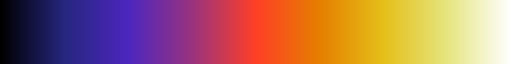

In [90]:
cmap_mode

In [91]:
# Colors and linestyles for each scenario (max four scenarios)
colors = {s: c for s,c in zip(scenarios, ['blue', 'purple', 'red', 'orange'][:len(scenarios)])}
linestyles = {s: l for s,l in zip(scenarios, ['-', ':', '--', '-.'][:len(scenarios)])}

In [92]:
# Load distances
distances = pd.read_csv(output_path + '/distances_centroids.csv')
distances = distances.set_index(['origin', 'destination'])

In [93]:
# Load the calibration dataset for validation
# if available
if False:
    mid2017 = pd.read_csv(input_path + 'transport_demand/calibration_all_trips_MiD2017.csv')
    # Replace LAU codes with NUTS IDs
    assert str(mid2017.loc[0, 'origin']).startswith('DE')
    # Rename modes and purposes
    mode_dict_mid = {1: 'rail_short', 2: 'rail_long',
                     3: 'coach', 4: 'bus', 5: 'air', 6: 'car', 7: 'walk'}
    mid2017['mode_model'] = mid2017['mode_model'].map(mode_dict_mid)
    mid2017['purpose_model'] = mid2017['purpose_model'].apply(lambda s: s.split('_')[0])
    mid2017['segment'] = mid2017['purpose_model'] + mid2017['car_avail'].map(
        {1: '_car', 0: '_no_car', 9: '_no_car'})
    mid2017 = mid2017[['mode_model', 'purpose_model', 'segment', 'origin', 'destination']]

# Networks

PT network and roads in the region

In [94]:
l_reac = gpd.read_file(network_path + 'de_rail_reactivation/links.geojson')
n_reac = gpd.read_file(network_path + 'de_rail_reactivation/nodes.geojson')

In [95]:
# Load PT networks
pt_links = {}
pt_nodes = {}
for scenario in scenarios:
    try:
        sm = stepmodel.read_json(model_path + scenario + '/de_pt_network_agg')
    except FileNotFoundError:
        sm = stepmodel.read_json(model_path + 'base' + '/de_pt_network_agg')
    sm.nodes = gpd.GeoDataFrame(sm.nodes, crs=sm.epsg)
    sm.links = gpd.GeoDataFrame(sm.links, crs=sm.epsg)
    sm.nodes = sm.nodes.loc[sm.nodes['geometry'].within(polygon.buffer(0.1))]
    sm.links = sm.links.loc[sm.links['a'].isin(sm.nodes.index)]
    pt_links[scenario] = sm.links.copy()
    pt_nodes[scenario] = sm.nodes.copy()
    del sm

Text(0.5, 0, 'speed [m/s]')

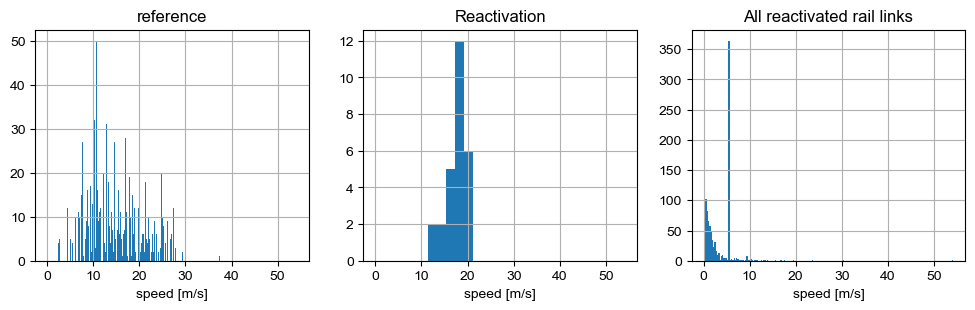

In [96]:
# Link speeds of rail_short
fig, axs = plt.subplots(1,3, figsize=(12,3), sharex='all')
for ax, scen in zip(axs[:2], scenarios[:2]):
    if not "Reactivation" in scen:
        l = pt_links[scen].loc[pt_links[scen]['route_type']=='rail_short'].copy()
    else:
        l = pt_links[scen].loc[pt_links[scen].index.str.contains('reac')].copy()
    l['length'] = skims.distance_from_geometry(l['geometry']).astype(int)
    l['speed'] = l['length'] / l['time']
    l['speed'].hist(bins=int(len(l)/5), ax=ax)
    ax.set_title(scen)
    ax.set_xlabel('speed [m/s]')
(l_reac['length']/l_reac['time']).hist(bins=int(len(l_reac)/5), ax=axs[-1])
axs[-1].set_title('All reactivated rail links')
axs[-1].set_xlabel('speed [m/s]')

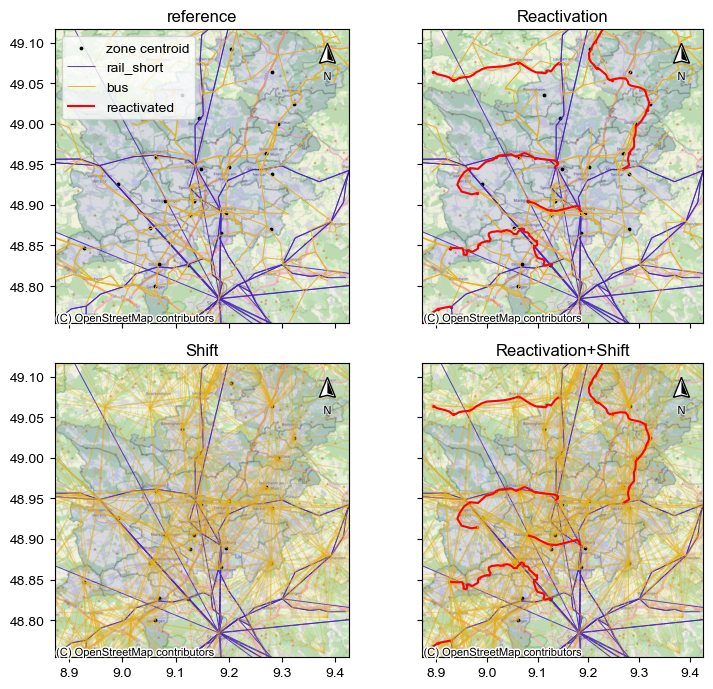

In [130]:
# Plot networks
fig, axs = plt.subplots(nrows=int(len(scenarios)/2), ncols=int(len(scenarios)/2), figsize=(8,7),
                        sharex='all', sharey='all')
for s,ax in zip(scenarios, axs.flat):
    ax.set_xlim(x0,x1)
    ax.set_ylim(y0,y1)
    # Zones
    ref.zones.loc[zone_ids].plot(color='blue', alpha=.1, edgecolor='black', ax=ax)
    # Centroids
    c = gpd.GeoDataFrame(geometry=[geometry.Point(x,y) for (x,y) in ref.zones.loc[zone_ids, ['lat', 'lon']].values], crs=4326)
    c.plot(color='black', label='zone centroid', markersize=3, ax=ax)
    # Links
    l = pt_links[s].drop_duplicates('geometry')
    l = l.loc[l['route_type']!='rail_long']
    l = l.loc[l['route_type']!='coach']
    l = l.loc[l['route_type']!='air']
    for mode in l['route_type'].unique():
        alpha = .9
        if mode=='bus' and 'Shift' in s: alpha=.2
        l.loc[(l['route_type']==mode) & ~(l.index.str.contains('reac')), 'geometry'
             ].plot(color=colormap[mode], label=mode, linewidth=.7, alpha=alpha, ax=ax)
    # Reactivation links
    if 'Reactivation' in s:
        #l_reac = l.loc[l.index.str.contains('reac')]
        #n_reac = pt_nodes[s].loc[pt_nodes[s].index.isin(set(list(l_reac['a'])+list(l_reac['b'])))]
        l_reac.plot(color='red', label='reactivated', ax=ax)
        n_reac.plot(color='red', markersize=2.15, ax=ax)
    try:
        cx.add_basemap(ax=ax, crs=4326, zoom=11, source=cx.providers.OpenStreetMap.DE)
    except HTTPError:
        pass
    ax.set_title(s)
    north_arrow(ax, rotation={"crs": ref.zones.crs, "reference": "center"},
                location="upper right", scale=.2, label={"fontsize":"small"}, shadow=False)
h,l = axs.flat[1].get_legend_handles_labels()
axs.flat[0].legend(h,l, loc='upper left')
fig.tight_layout()
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_networks_pt.png', dpi=dpi)
#plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_networks_pt.eps')

# Composite cost

Percieved cost averaged over all modes by origin-destination pair

For region of interest

In [98]:
# Load CC
cc = {}
for scenario in scenarios:
    df = pd.read_csv(output_path + scenario + '/mode_choice_od_composite_cost.csv')
    df = df.loc[df['origin'].isin(zone_ids)]
    cc[scenario] = df

In [99]:
# Define distance classes
#bins = [0, 20, 40, 60, 80, 100, 150, 200, 300, 500, 700, 1000]
#labels = ['{}-{}km'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)]
bins = list(range(0,1020, 10))
labels = bins[:-1]
for scenario in scenarios:
    cc[scenario]['dist'] = cc[scenario].set_index(['origin', 'destination']).index.map(distances.to_dict()['length'])
    cc[scenario]['bins'] = pd.cut(cc[scenario]['dist'], bins=bins, labels=labels)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\3353002562.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cc[scenario].notna().all(axis=1)].groupby('bins')[seg].mean(),


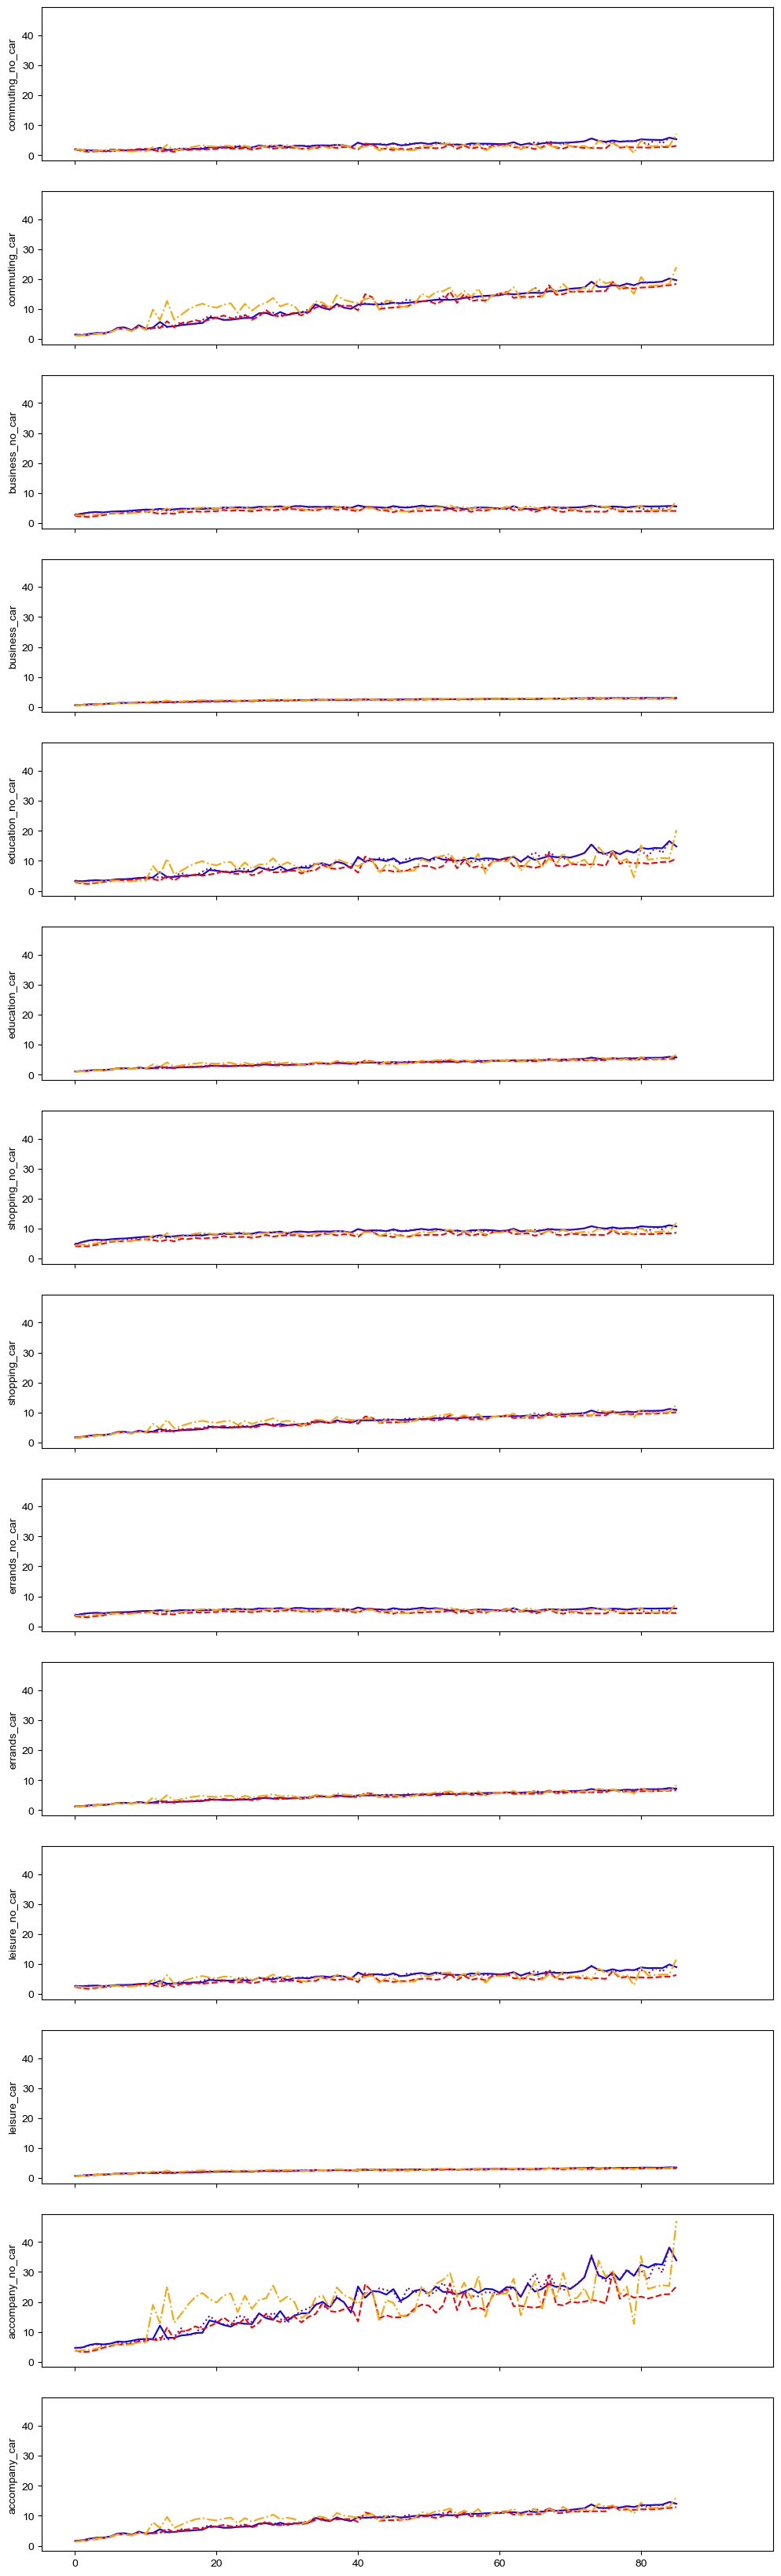

In [100]:
fig, ax = plt.subplots(nrows=len(segments), ncols=1, figsize=(12, 3*len(segments)),
                       sharex='all', sharey='all')
i = 0
for seg in segments:
    for scenario in scenarios:
        ax[i].plot(np.arange(len(labels)), cc[scenario].loc[
            cc[scenario].notna().all(axis=1)].groupby('bins')[seg].mean(),
                  color=colors[scenario], linestyle=linestyles[scenario])
    ax[i].set_ylabel(seg)
    i += 1

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2149662808.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2149662808.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2149662808.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

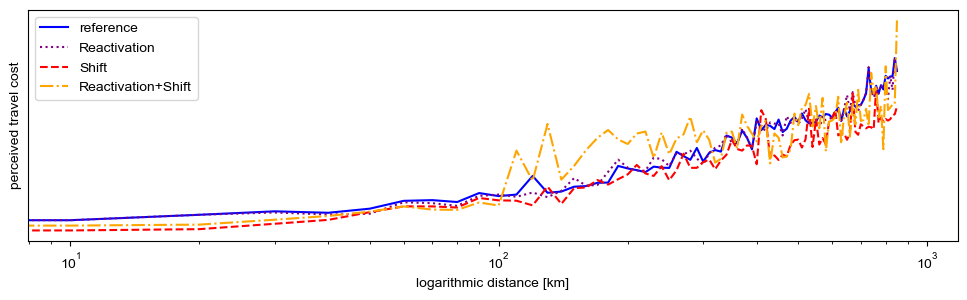

In [101]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,3),
                       sharex='all', sharey='row')
ind = labels
for scenario in scenarios:
    mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)].groupby('bins')[segments].mean().mean(axis=1)
    ax.plot(ind, mean_cc, label=scenario, color=colors[scenario], linestyle=linestyles[scenario])
ax.set_ylabel('perceived travel cost')
ax.set_yticks([])
ax.set_xscale('log')
ax.set_xlabel('logarithmic distance [km]')
ax.legend(loc='upper left')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_cc_all_distance.png', dpi=dpi)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2643684922.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2643684922.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby('bins')[segments].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\2643684922.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence

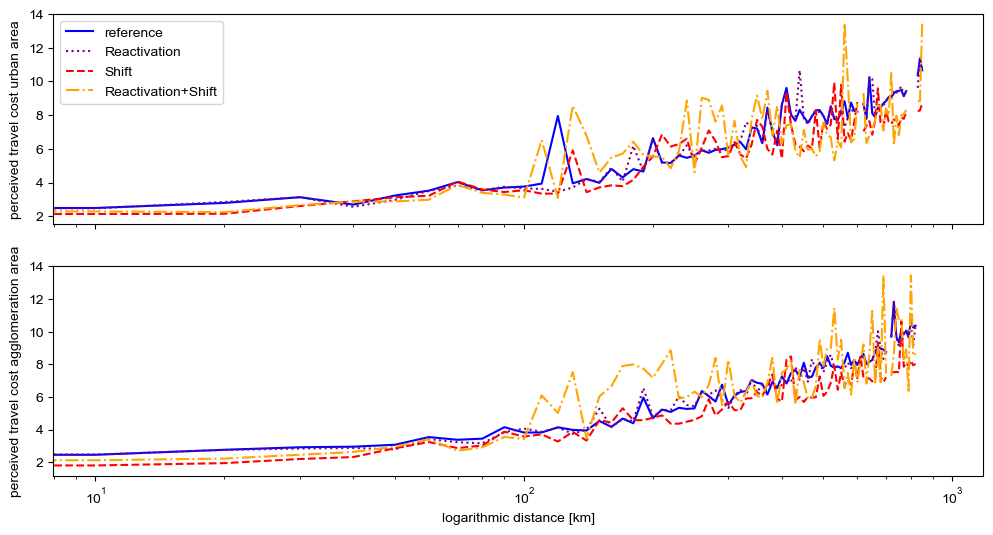

In [102]:
# By urbanisation
urb = list(ref.zones.loc[zone_ids, 'urbanisation'].unique())
urb.sort()
fig, ax = plt.subplots(nrows=len(urb), ncols=1, figsize=(12,3*len(urb)),
                       sharex='all', sharey='row')
ind = labels
for u in urb:
    zones = list(ref.zones.loc[ref.zones['urbanisation']==u].index)
    for scenario in scenarios:
        mean_cc = cc[scenario].loc[(cc[scenario].notna().all(axis=1)) & (cc[scenario]['origin'].isin(zones))
                                  ].groupby('bins')[segments].mean().mean(axis=1)
        i = urb.index(u)
        ax[i].plot(ind, mean_cc, label=scenario, color=colors[scenario], linestyle=linestyles[scenario])
    ax[i].set_ylabel('perceived travel cost {} area'.format({1:'urban', 2:'agglomeration', 3:'rural'}[u]))
    ax[i].set_xscale('log')
ax[0].legend(loc='upper left')
ax[-1].set_xlabel('logarithmic distance [km]')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_cc_all_distance_urbanisation.png', dpi=dpi)

# Volumes

Number of trips per year

For region of interest, all zones near reactivation, and Germany

In [103]:
# Load volumes
vols = {}
vols_region = {}
vols_regions_all = {}
for scenario in scenarios:
    distr = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_distribution')
    if len(set(segments) - set(distr.volumes.columns)) == 0:
        vols[scenario] = distr.volumes
    else:
        choice = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_choice')
        vols[scenario] = pd.merge(choice.volumes, distr.volumes, how='outer', on=['origin', 'destination']).reset_index(drop=True)

volumes: 100%|███████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.25it/s]


### Distance distribution

inter-zonal trips

In [104]:
# Define distance classes
#bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150, 200, 300, 500, 1000]
#labels = ['{}-{}km'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)]
bins = list(range(0,1020, 10))
labels = bins[:-1]
for scenario in scenarios:
    vol = vols[scenario]
    vol['dist'] = vol.set_index(['origin', 'destination']).index.map(distances.to_dict()['length'])
    vol['dist'] = vol['dist'].clip(lower=.1)
    vol['bins'] = pd.cut(vol['dist'], bins=bins, labels=labels)
for scenario in scenarios:
    vols_region[scenario] = vols[scenario].loc[vols[scenario]['origin'].isin(zone_ids)]
    vols_regions_all[scenario] = vols[scenario].loc[vols[scenario]['origin'].isin(all_zone_ids)]

In [105]:
# Sum up volumes
vol_df = pd.DataFrame()
vol_region_df = pd.DataFrame()
vol_regions_all_df = pd.DataFrame()
for scenario in scenarios:
    for df, extent in zip([vol_df, vol_region_df, vol_regions_all_df], [vols, vols_region, vols_regions_all]):
        df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
        df[scenario] = df[[scenario+' '+seg for seg in segments]].sum(axis=1)
        df[scenario+' with car'] = df[[scenario+' '+seg for seg in segments if not '_no_car' in seg]].sum(axis=1)
        df[scenario+' without car'] = df[[scenario+' '+seg for seg in segments if '_no_car' in seg]].sum(axis=1)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[[scenario+' '+seg for seg in segments]] = extent[scenario].groupby('bins')[segments].sum()
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1738533835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1965757843.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bins')[cols].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1965757843.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bins')[cols].mean().mean(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\1965757843.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

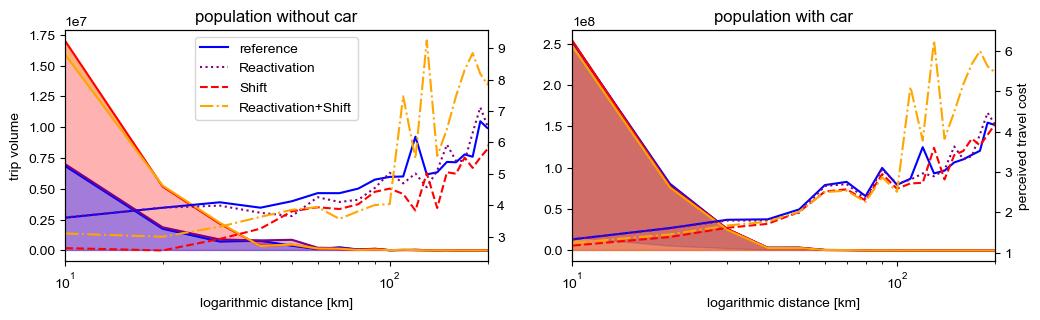

In [106]:
# plot with CC by car availability - regional
try:
    _ = cc[scenarios[0]] # is CC loaded?
    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12,3))
    ind = list(range(0,1020, 10))[:-1]
    prev_line = [0 for _ in ind]
    
    # Plot trip frequency
    for ax, seg in zip(axs, [' without car', ' with car']):
        ax.set_title('population'+seg)
        for scenario in scenarios:
            ax.plot(ind, vol_region_df[scenario+seg], color=colors[scenario])
            line_data = vol_region_df[scenario+seg]
            if line_data[0] > prev_line[0]:
                ax.fill_between(ind, prev_line, line_data, color=colors[scenario], alpha=.3)
                prev_line = vol_region_df[scenario+seg]
            else:
                ax.fill_between(ind, 0, line_data, color=colors[scenario], alpha=.3)
        if 'without' in seg: ax.set_ylabel('trip volume')
        ax.set_xlabel('logarithmic distance [km]')
        ax.set_xscale('log')
        ax.set_xlim(10,200)

        # Add CC
        ax2 = ax.twinx()
        #ax2.set_yticks([])
        for scenario in scenarios:
            if 'without' in seg:
                cols = [s for s in segments if '_no_car' in s]
            else:
                cols = [s for s in segments if not '_no_car' in s]
                ax2.set_ylabel('perceived travel cost')
            mean_cc = cc[scenario].loc[cc[scenario].notna().all(axis=1)]\
                .groupby('bins')[cols].mean().mean(axis=1)
            mean_cc[1000] = mean_cc[990]
            ax2.plot(ind[:22], mean_cc[:22], label=scenario,
                     color=colors[scenario], linestyle=linestyles[scenario])
        if 'without' in seg: ax2.legend(loc='upper center')
        
    plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_distance_distribution_cc_car_ownership.png', dpi=dpi, bbox_inches="tight")
except KeyError:
    pass

# Network connectivity

Look at connectivity of specific mode

In [131]:
# Load data
# For destination zones with centroids up to Xkm apart
radius = 50000
mode = ['rail_short', 'bus']
destinations = ref.zones.loc[ref.zones['geometry'].to_crs(3857).centroid.within(
    ref.zones.loc[zone_ids, 'geometry'].to_crs(3857).union_all().buffer(radius))].index
conn = {}
for scenario in scenarios:
    sm = stepmodel.read_zippedpickles(model_path + scenario + '/de_pt_los')
    conn[scenario] = sm.pt_los.loc[(sm.pt_los['origin'].isin(zone_ids))
                                   & (sm.pt_los['destination'].isin(destinations))
                                   & (sm.pt_los['route_type'].isin(mode))]
    del sm

pt_los: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.05it/s]


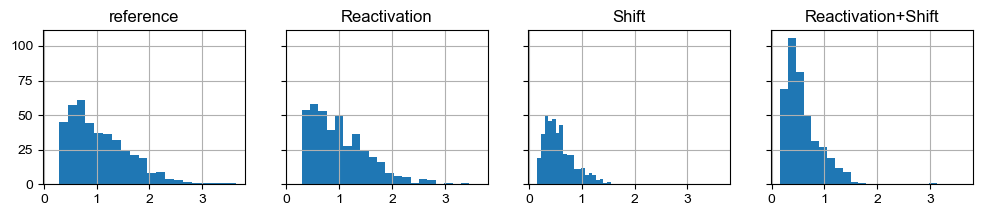

In [132]:
# fastest routes
fig, ax = plt.subplots(ncols=len(scenarios), figsize=(12,2), sharex='all', sharey='all')
for s,i in zip(scenarios, range(len(scenarios))):
    conn[s].groupby(['origin', 'destination'])['time'].min().hist(ax=ax[i], bins=20)
    ax[i].set_title(s)

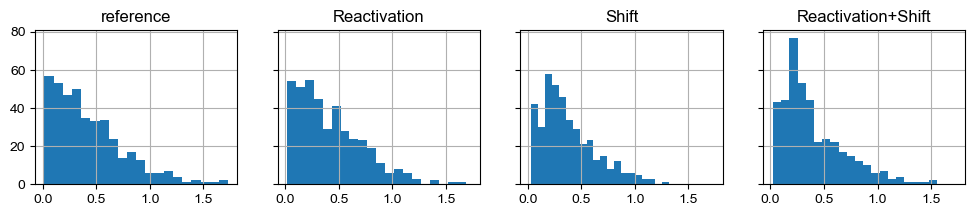

In [133]:
# fastest routes - in-vehicle time
fig, ax = plt.subplots(ncols=len(scenarios), figsize=(12,2), sharex='all', sharey='all')
for s,i in zip(scenarios, range(len(scenarios))):
    (conn[s].groupby(['origin', 'destination'])['in_vehicle_time'].min() / 3600).hist(ax=ax[i], bins=20)
    ax[i].set_title(s)

In [134]:
def plot_diff_zones(attr, operation='min'):
    half = int(len(scenarios)/2)
    fig, axs = plt.subplots(nrows=1, ncols=half+1, figsize=(12,5), width_ratios=[1,1,0.05])
    vmin=0.7
    vmax=1.3
    for i,ax in zip(range(1, half+2, 2), axs[:half]):
        ax.set_xlim(x0,x1)
        ax.set_ylim(y0,y1)
        # diff
        zones = ref.zones.loc[zone_ids].copy()
        #zones['attr'] = zones.index.map(conn[scenarios[i]].groupby('origin')[attr].mean())
        #zones['attr_ref'] = zones.index.map(conn[scenarios[i-1]].groupby('origin')[attr].mean())
        #zones['attr_diff'] = (zones['attr_ref'] / zones['attr'])#.fillna(1)
        right = conn[scenarios[i]].groupby(['origin', 'destination']).agg({attr:operation})
        left = conn[scenarios[i-1]].groupby(['origin', 'destination']).agg({attr:operation})
        od_merge = pd.merge(left, right, how='outer', left_index=True, right_index=True, suffixes=('_ref', ''))
        od_merge['attr_diff'] =  od_merge[attr] / od_merge[attr+'_ref']
        zones['attr_diff'] = od_merge.groupby(level=0)['attr_diff'].mean()
        vmax = min(max(vmax, zones['attr_diff'].max()), 1.99)
        vmin = 1 - (vmax - 1)
        zones.plot(column='attr_diff', cmap='coolwarm', edgecolor='black', ax=ax,
                   legend=True, cax=axs[half], vmin=vmin, vmax=vmax,
                   missing_kwds={"color": "lightgrey", "hatch": "///"})
        # Links
        l = pt_links[scenarios[i]].drop_duplicates('geometry')
        l = l.loc[l['route_type']=='rail_short']
        l.loc[~l.index.str.contains('reac')].plot(color=colormap['rail_short'], label='rail_short', linewidth=.7, ax=ax)
        # Reactivation links
        #l_reac = l.loc[l.index.str.contains('reac')]
        l_reac.plot(color='red', label='reactivated', ax=ax)
        #n_reac = pt_nodes[scenarios[i]].loc[
        #    pt_nodes[scenarios[i]].index.isin(set(list(l_reac['a'])+list(l_reac['b'])))]
        n_reac.plot(color='red', markersize=2.1, ax=ax)
        #try: cx.add_basemap(ax=ax, crs=4326, zoom=11, source=cx.providers.OpenStreetMap.DE)
        #except HTTPError: pass
        ax.set_title(scenarios[i] + ' compared to ' + scenarios[i-1])
    h,l = axs[1].get_legend_handles_labels()
    axs[0].legend(h,l, loc='upper left')
    axs[half].set_ylabel(operation + ' ' + attr.replace('_', ' ') + ' ratio')
    fig.tight_layout()
    plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_rail_short_'+attr+'_diff_'+str(int(radius/1000))+'km.png', dpi=dpi)
    plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_rail_short_'+attr+'_diff_'+str(int(radius/1000))+'km.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


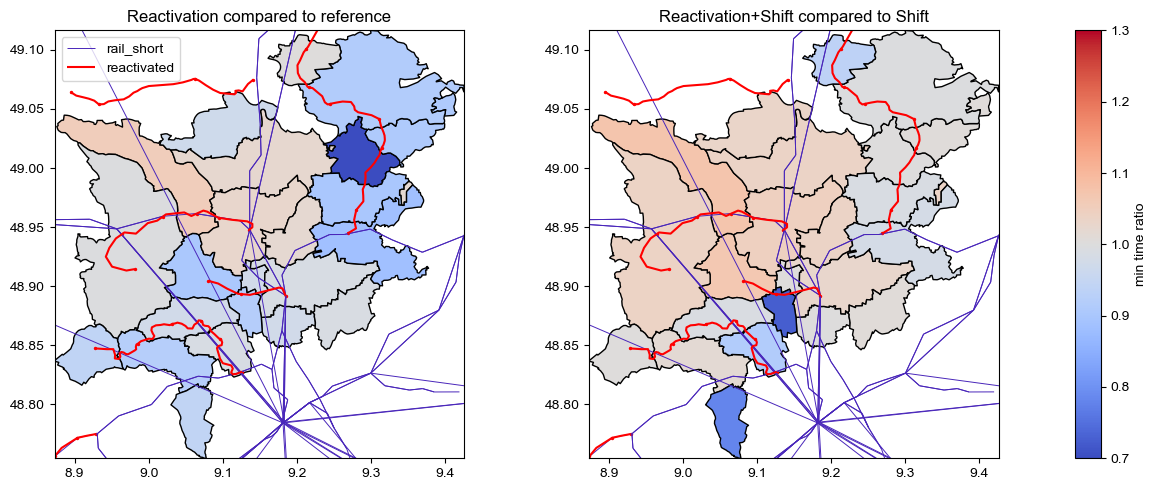

In [135]:
# Time
plot_diff_zones('time')

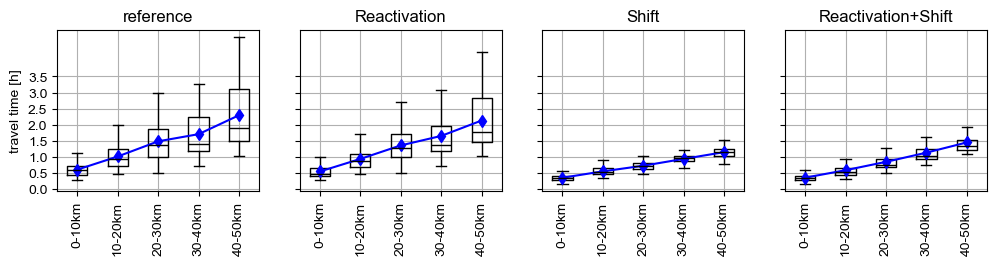

In [136]:
# path durations
fig, ax = plt.subplots(ncols=len(scenarios), figsize=(12,2.1), sharex='all', sharey='all')
bins_here = [b for b in bins if b<radius/1000]
ind = [i+1 for i in range(len(bins_here))]
max_time = conn[scenario_ref]['time'].quantile(.95)
yticks = [i/10 for i in range(0, int(max_time*10)+1, 5)]
for s,i in zip(scenarios, range(len(scenarios))):
    conn[s]['bin'] = pd.cut(conn[s]['length']/1000, bins=bins, labels=labels).astype(int)
    conn[s].loc[conn[s]['bin']<=bins_here[-1]].groupby('bin').boxplot(
        subplots=False, column='time', ax=ax[i], sym='',
        boxprops={'color':'black'}, medianprops={'color':'black'}, whiskerprops={'color':'black'})
    av = conn[s].loc[conn[s]['bin']<=bins_here[-1]].groupby('bin')['time'].mean()
    ax[i].plot(ind, av, color='blue', marker='d')
    ax[i].set_title(s)
    ax[i].set_xticks(ind, [str(bins[i])+'-'+str(bins[i+1])+'km' for i in range(len(bins_here))], rotation=90)
    ax[i].set_yticks(yticks)
ax[0].set_ylabel('travel time [h]')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_rail_short_time_distribution_'+str(int(radius/1000))+'km.png', dpi=dpi, bbox_inches = "tight")
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_rail_short_time_distribution_'+str(int(radius/1000))+'km.eps', bbox_inches = "tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


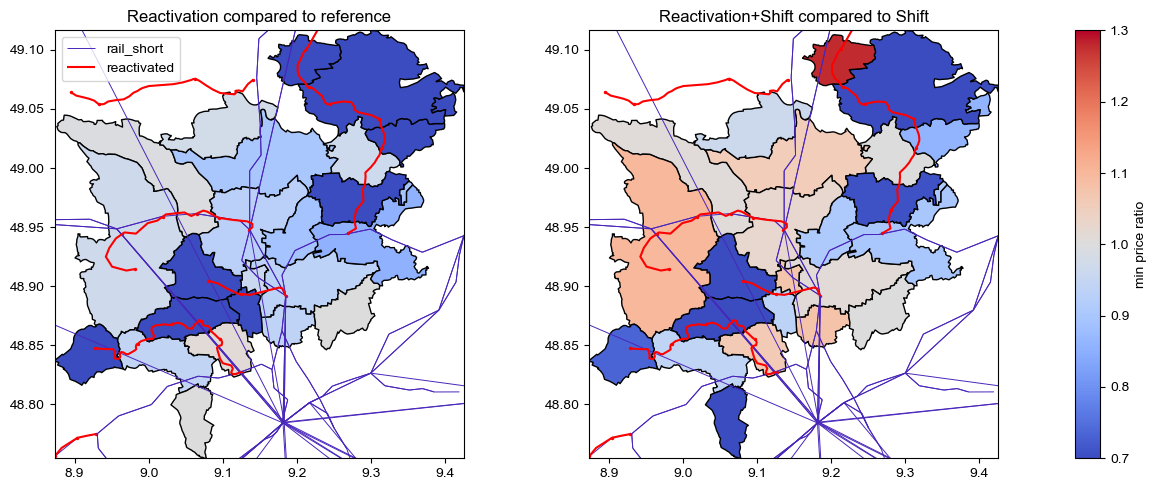

In [137]:
# Price
seg_share = vols[scenario_ref][segments].sum() / vols[scenario_ref][segments].sum().sum()
for s in scenarios:
    conn[s]['price'] = conn[s][[seg+'_price' for seg in segments]].multiply(list(seg_share), axis=1).sum(axis=1)
plot_diff_zones('price')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


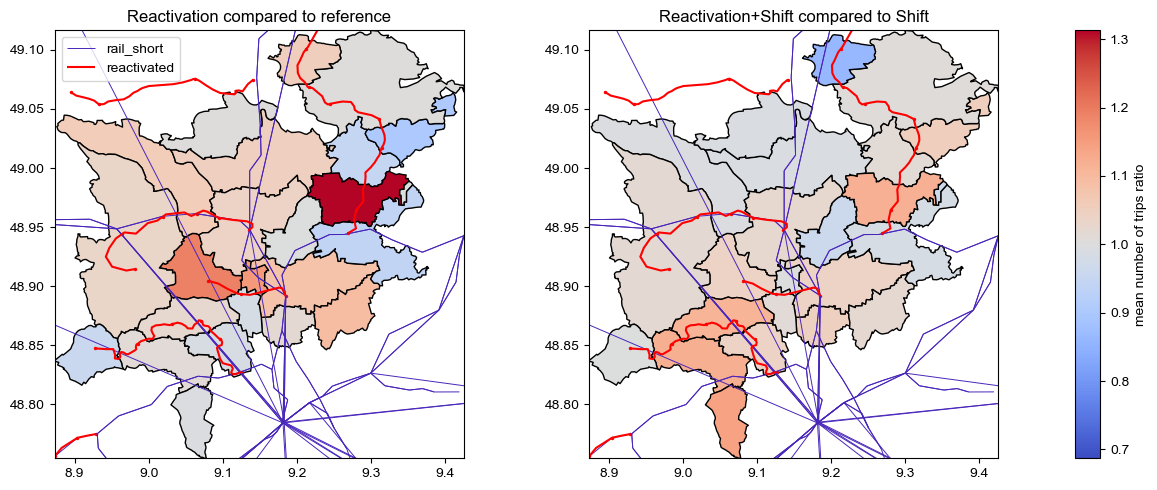

In [138]:
# Number of trips
for s in scenarios:
    od = vols[s].loc[(vols[s]['origin'].isin(zone_ids)) & (vols[s]['destination'].isin(destinations))
                    ].groupby(['origin', 'destination'])[segments].sum().sum(axis=1).rename('trips')
    conn[s]['number_of_trips'] = conn[s].merge(od.to_frame(), how='left', left_on=['origin', 'destination'], right_index=True)['trips']
plot_diff_zones('number_of_trips', 'mean')

In [115]:
#scenario = 'Reactivation'
#links_reac = [i for i in pt_links[scenario].index if 'reac' in i]
#conn[scenario].loc[conn[scenario]['link_path'].apply(lambda l: max(['reac' in i for i in l]))]

# Modal split

by main mode. Inter-zonal and inner-zonal. All traffic originating from zones of interest.

In [116]:
# Load probabilities and merge with volumes to create an OD matrix
ods = {}
ods_region = {}
ods_regions_all = {}
inner_od = {}
utility = {}
for scenario in scenarios:
    # inter-zonal
    sm = stepmodel.read_zippedpickles(model_path + scenario + '/de_logit')
    od = sm.probabilities.set_index(['origin', 'destination', 'segment'])\
        .drop(columns=['root'], errors='ignore').unstack('segment')
    modes = set(od.columns.get_level_values(0))
    if len(['rail' for mode in modes if 'rail' in mode]) > 1:
        od.drop('rail', axis=1, inplace=True)
    if len(['car' for mode in modes if 'car' in mode]) > 1:
        od.drop('car', axis=1, inplace=True)
    vol = vols[scenario].loc[vols[scenario]['origin']!=vols[scenario]['destination']]
    vol[['origin', 'destination']] = vol[['origin', 'destination']].astype(str)
    vol = vol.set_index(['origin', 'destination']).drop(columns=['bins', 'dist', 'index'], errors='ignore')
    od_vols = pd.DataFrame(index=vol.index, columns=od.columns)
    for mode in set(od.columns.get_level_values(0)):
        od_vols[mode] = (od[mode] * vol).fillna(0)
    ods[scenario] = od_vols
    # get utility
    u = sm.pt_los[[c for c in sm.pt_los.columns if 'utility' in c and len(c)==2]
                 ].multiply(list(seg_share), axis=1).sum(axis=1)
    utility[scenario] = u
    del sm
    
    # inner-zonal
    inner = pd.read_excel(output_path + scenario + '/inner_zone.xlsx', sheet_name='inner_zone')
    inner['origin'] = inner['origin'].astype(str)
    inner['destination'] = inner['origin']
    inner['mode'] = inner['mode'].replace({'rail': 'rail_short'})
    inner.rename(columns={'mode': 'route_type'}, inplace=True)
    inner = inner.set_index(['origin', 'destination', 'route_type', 'segment'])['volumes'].unstack(['route_type', 'segment'])
    inner_od[scenario] = inner
    
    # Consolidate
    ods[scenario] = pd.concat([od_vols, inner]).fillna(0)
    ods_region[scenario] = ods[scenario].loc[[str(i) for i in zone_ids]]
    ods_regions_all[scenario] = ods[scenario].loc[[str(i) for i in all_zone_ids]]

utility_values: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:15<00:00,  1.74s/it]
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\4000487112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol[['origin', 'destination']] = vol[['origin', 'destination']].astype(str)
utility_values: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:13<00:00,  1.48s/it]
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_19696\4000487112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


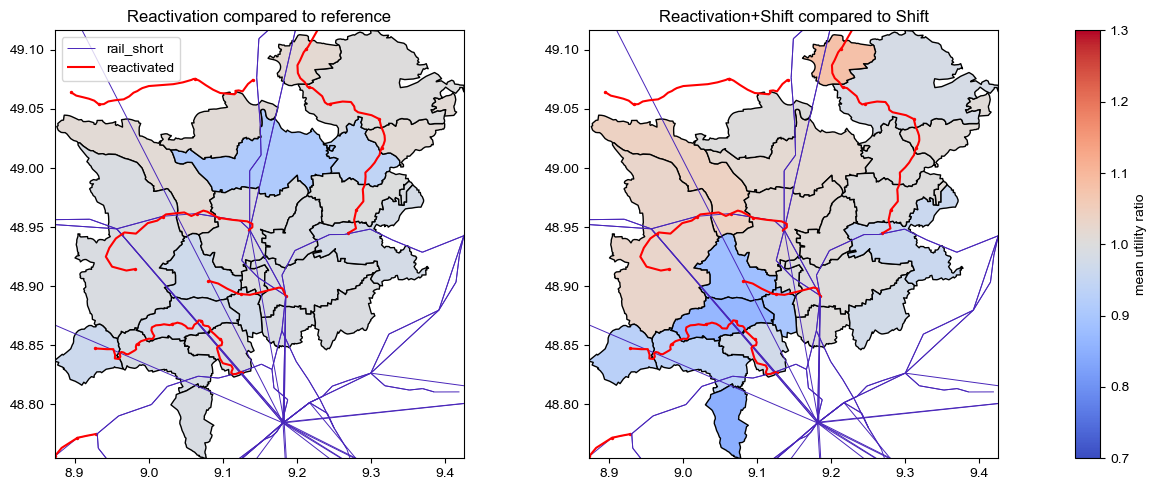

In [117]:
# Travel utility change
for s in scenarios:
    conn[s]['utility'] = utility[s]
    conn[s]['utility'] = conn[s]['utility'].astype(float)
plot_diff_zones('utility', 'mean')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


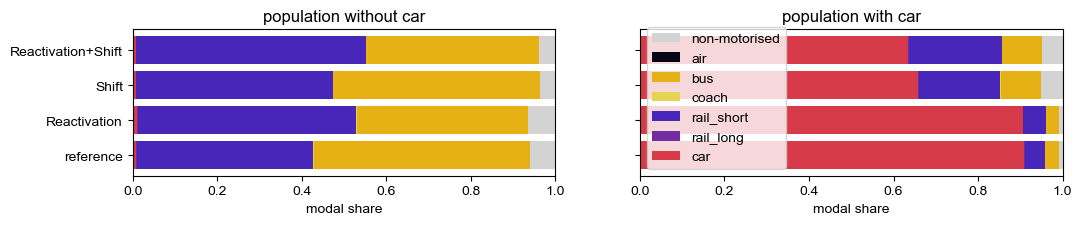

In [118]:
# Modal split within and between zones
# Horizontal stacked bar chart
fig, ax = plt.subplots(1,2, figsize=(12,1.9))
y_pos = range(len(scenarios))
without = [s for s in segments if '_no_car' in s]
with_car = [s for s in segments if not '_no_car' in s]
for i, segs, title in zip([0,1], [without, with_car], ['population without car', 'population with car']):
    left = [0] * len(y_pos)
    od_sums = {s: ods_region[s].loc[:, ods_region[s].columns.get_level_values('segment').isin(segs)].sum().sum() for s in scenarios}
    for label in list(colormap.keys()):
        mode = label if label != 'non-motorised' else 'walk'
        values = [ods_region[s][mode][segs].sum().sum() / od_sums[s]
                  if mode in ods_region[s].columns.get_level_values(0) else 0
                  for s in scenarios]
        if sum(values) > 0:
            ax[i].barh(y=y_pos, height=0.8, width=values, left=left, label=label, color=colormap[label])
            left = [l + v for l, v in zip(left, values)]
    ax[i].set_xlabel('modal share')
    ax[i].set_xlim((0,1))
    ax[i].set_title(title)

h,l = ax[1].get_legend_handles_labels()
ax[1].legend(h[::-1], l[::-1], loc='lower left')
ax[0].set_yticks(y_pos, scenarios)
ax[1].set_yticks(y_pos, [])

plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_trips.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_trips.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


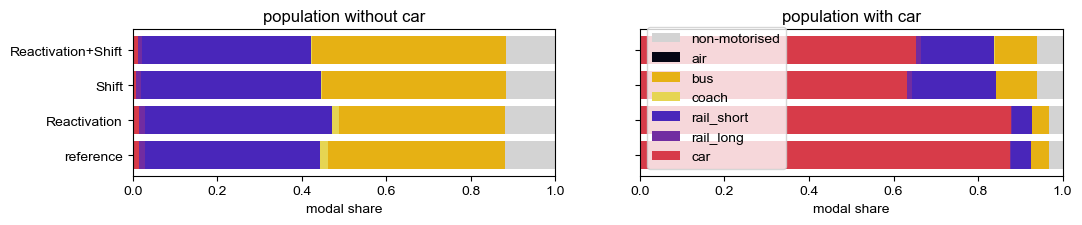

In [119]:
# Modal split within and between zones
# Horizontal stacked bar chart
# Germany
fig, ax = plt.subplots(1,2, figsize=(12,1.9))
y_pos = range(len(scenarios))
without = [s for s in segments if '_no_car' in s]
with_car = [s for s in segments if not '_no_car' in s]
for i, segs, title in zip([0,1], [without, with_car], ['population without car', 'population with car']):
    left = [0] * len(y_pos)
    od_sums = {s: ods[s].loc[:, ods[s].columns.get_level_values('segment').isin(segs)].sum().sum() for s in scenarios}
    for label in list(colormap.keys()):
        mode = label if label != 'non-motorised' else 'walk'
        values = [ods[s][mode][segs].sum().sum() / od_sums[s]
                  if mode in ods[s].columns.get_level_values(0) else 0
                  for s in scenarios]
        if sum(values) > 0:
            ax[i].barh(y=y_pos, height=0.8, width=values, left=left, label=label, color=colormap[label])
            left = [l + v for l, v in zip(left, values)]
    ax[i].set_xlabel('modal share')
    ax[i].set_xlim((0,1))
    ax[i].set_title(title)

h,l = ax[1].get_legend_handles_labels()
ax[1].legend(h[::-1], l[::-1], loc='lower left')
ax[0].set_yticks(y_pos, scenarios)
ax[1].set_yticks(y_pos, [])

plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_trips.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_trips.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


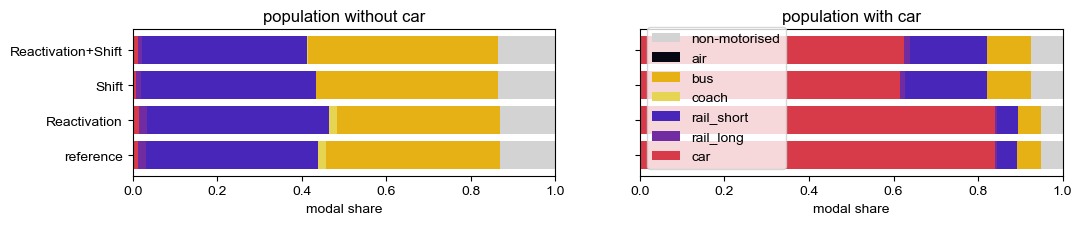

In [120]:
# Modal split within and between zones
# Horizontal stacked bar chart
# Germany - only reactivated zones
fig, ax = plt.subplots(1,2, figsize=(12,1.9))
y_pos = range(len(scenarios))
without = [s for s in segments if '_no_car' in s]
with_car = [s for s in segments if not '_no_car' in s]
for i, segs, title in zip([0,1], [without, with_car], ['population without car', 'population with car']):
    left = [0] * len(y_pos)
    od_sums = {s: ods_regions_all[s].loc[:, ods_regions_all[s].columns.get_level_values('segment').isin(segs)].sum().sum() for s in scenarios}
    for label in list(colormap.keys()):
        mode = label if label != 'non-motorised' else 'walk'
        values = [ods_regions_all[s][mode][segs].sum().sum() / od_sums[s]
                  if mode in ods_regions_all[s].columns.get_level_values(0) else 0
                  for s in scenarios]
        if sum(values) > 0:
            ax[i].barh(y=y_pos, height=0.8, width=values, left=left, label=label, color=colormap[label])
            left = [l + v for l, v in zip(left, values)]
    ax[i].set_xlabel('modal share')
    ax[i].set_xlim((0,1))
    ax[i].set_title(title)

h,l = ax[1].get_legend_handles_labels()
ax[1].legend(h[::-1], l[::-1], loc='lower left')
ax[0].set_yticks(y_pos, scenarios)
ax[1].set_yticks(y_pos, [])

plt.savefig(output_path + '_scenario_validation_regional/Germany_reactivated_zones_modal_split_trips.png', dpi=dpi)
plt.savefig(output_path + '_scenario_validation_regional/Germany_reactivated_zones_modal_split_trips.eps')

In [121]:
# Define distance classes
'''bins = [0, 20, 30, 40, 50, 60, 70, 80, 100, 200, 1000]
labels = ['<{}km'.format(bins[i+1]) for i in range(len(bins)-1)]
d = distances.reset_index()
d[['origin', 'destination']] = d[['origin', 'destination']].astype(str)
d = d.set_index(['origin', 'destination'], drop=True)
for s in scenarios:
    ods[s]['dist'] = ods[s]['car'].merge(d, how='left', left_index=True, right_index=True)['length']
    ods[s]['bins'] = pd.cut(ods[s]['dist'], bins=bins, labels=labels)
    ods[s].drop('dist', axis=1, inplace=True)'''
print(' ')

# Passenger kilometre

pkm = #trips * distance

In [122]:
# Load pkm
pkm = {}
for s in scenarios:
    df = pd.read_csv(output_path + s + '/pkm_inter_main_mode.csv')
    df = df.groupby(['origin', 'mode'])['pkm'].sum().unstack('mode').fillna(0)
    pkm[s] = df#[[mode for mode in df.columns if df[mode].sum()>df.sum().sum()*0.001]]

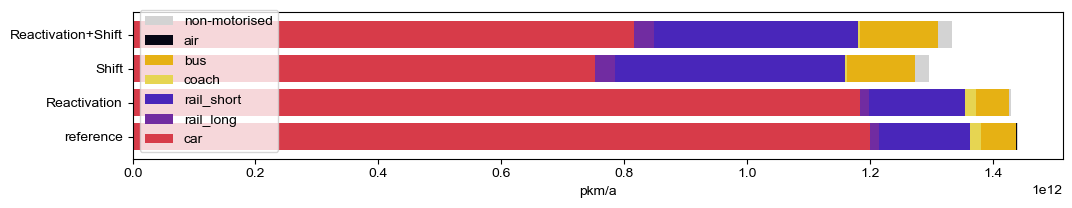

In [123]:
# Pkm as bar plot for entire Germany
fig, ax = plt.subplots(figsize=(12,1.9))
pkm_df = pd.DataFrame()
for s in scenarios:
    pkm_df[s] = pkm[s].sum()
pkm_df = pkm_df.rename(index={'walk': 'non-motorised'}).fillna(0)
modes = [m for m in colormap.keys() if m in pkm_df.index]
pkm_df.T[modes].plot.barh(stacked=True, width=0.8, ax=ax, legend=None,
                          color=[colormap[m] for m in modes])
ax.set_xlabel('pkm/a')
h,l = ax.get_legend_handles_labels()
plt.legend(h[::-1], l[::-1], loc='lower left')
plt.savefig(output_path + '_scenario_validation_regional/Germany_modal_split_pkm.png', dpi=dpi, bbox_inches="tight")

In [124]:
# absolute Germany
pkm_df/1e9

,reference,Reactivation,Shift,Reactivation+Shift
mode,,,,
air,0.657418,0.623861,0.213237,0.129596
bus,56.888373,52.952187,110.638364,126.625175
car,1200.695185,1184.427516,751.910480,815.934427
coach,17.801976,17.733092,3.759451,3.753608
rail_long,14.570343,14.668336,32.699189,31.990434
rail_short,148.037515,156.286583,374.091819,332.414965
non-motorised,2.905079,2.905048,23.376258,23.378964


In [125]:
# absolute sum Germany
pkm_df.sum()/1e9

reference             1441.555889
Reactivation          1429.596623
Shift                 1296.688799
Reactivation+Shift    1334.227169
dtype: float64

In [126]:
# Shares Germany
pkm_df / pkm_df.sum()

,reference,Reactivation,Shift,Reactivation+Shift
mode,,,,
air,0.000456,0.000436,0.000164,0.000097
bus,0.039463,0.037040,0.085324,0.094905
car,0.832916,0.828505,0.579870,0.611541
coach,0.012349,0.012404,0.002899,0.002813
rail_long,0.010107,0.010260,0.025217,0.023977
rail_short,0.102693,0.109322,0.288498,0.249144
non-motorised,0.002015,0.002032,0.018028,0.017522


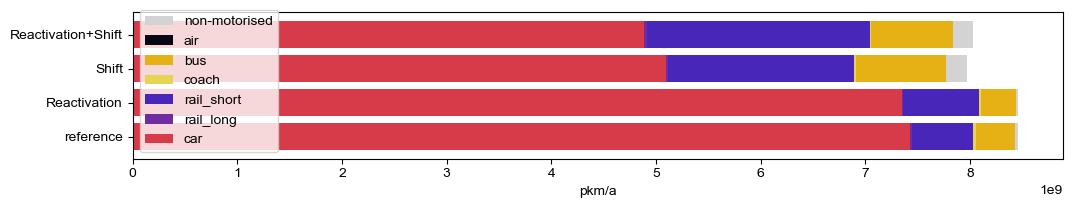

In [127]:
# Pkm as bar plot for the model region
fig, ax = plt.subplots(figsize=(12,1.9))
pkm_df = pd.DataFrame()
for s in scenarios:
    pkm_df[s] = pkm[s].loc[zone_ids].sum()
pkm_df = pkm_df.rename(index={'walk': 'non-motorised'}).fillna(0)
modes = [m for m in colormap.keys() if m in pkm_df.index]
pkm_df.T[modes].plot.barh(stacked=True, width=0.8, ax=ax, legend=None,
                          color=[colormap[m] for m in modes])
ax.set_xlabel('pkm/a')
h,l = ax.get_legend_handles_labels()
plt.legend(h[::-1], l[::-1], loc='lower left')
plt.savefig(output_path + '_scenario_validation_regional/'+region_name+'_modal_split_pkm.png', dpi=dpi, bbox_inches = "tight")

In [128]:
# Shares region
pkm_df / pkm_df.sum()

,reference,Reactivation,Shift,Reactivation+Shift
mode,,,,
air,0.000000,0.000000,0.000000,0.000000
bus,0.044717,0.039590,0.107502,0.097101
car,0.878452,0.868342,0.639130,0.608287
coach,0.003241,0.002480,0.002783,0.002091
rail_long,0.001697,0.001699,0.003044,0.003544
rail_short,0.068985,0.085091,0.222270,0.265222
non-motorised,0.002909,0.002798,0.025272,0.023756


In [129]:
# Total pkm
pkm_df.sum()

reference             8.457631e+09
Reactivation          8.461547e+09
Shift                 7.967786e+09
Reactivation+Shift    8.027006e+09
dtype: float64

# Cost estimation

The corresponding department made available the arithmetic mean and median reactivation cost at 7.78 and 4.02\,million\,EUR/km, respectively. For the purpose of this analysis, we assume that all potential projects become reactivated, which amount to 4712\,km. It is deemed reasonable to assume above mean value because projects are not selected based on economic indicators. The total investment accounts for 36.7\,billion\,EUR.

Shift: three large investments account for local and regional PT infrastructure on a German aggregate level.
1) Railway network refurbishment and extension to facilitate undisrupted, reliable operation is estimated to cost 52\,billion\,EUR, including infrastructure measures from the German national transport infrastructure plan and additional 10\,billion\,EUR for realisation of a unified and reliable interval timetable, facilitating short transfer times. This investment was initially planned by 2030.
2) Large intermodal mobility hubs with park-and-ride options at city borders are estimated at 50\,million\,EUR each, totalling 19.2\,billion\,EUR.
3) DRT services are included with purchase cost for a fleet of mini vans that covers the entire nation's demand at 98.3\,billion\,EUR (assuming vehicle prices for 2030).

Shift: Distribute by population.

In [38]:
cost_shift_pp = 169500000000 / 82009200 # EUR per person
cost_shift_pp

2066.8412812221068

In [37]:
# Reactivation cost Germany per person
length = l_reac['length'].sum() / 1e3
pop = ref.zones['population'].sum()
cost_reac_pp = length * 7780000 / pop
cost_reac_pp

np.float64(447.0324259535298)

In [52]:
cost_reac_pp_all = length * 7780000 / ref.zones.loc[all_zone_ids, 'population'].sum()
cost_reac_pp_all

np.float64(1278.5399920042996)

In [35]:
# Regional reactivation depends on local new railway lines
# Stuttgart region = 1239.66 EUR pp
# Sigmaringen region = 3856.34 EUR pp
l_reac_region = l_reac.loc[l_reac['geometry'].within(polygon.envelope)]
length = l_reac_region['length'].sum() / 1e3
pop = ref.zones.loc[zone_ids, 'population'].sum()
cost_reac_pp_region = length * 7780000 / pop
cost_reac_pp_region

np.float64(3856.3445538120045)

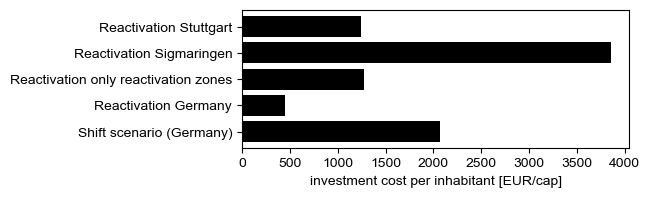

In [54]:
cost_reac_pp_stuttgart = 1239.66
cost_reac_pp_sigmaringen = 3856.34

fig, ax = plt.subplots(1,1, figsize=(5,1.8))
labels = ['Reactivation Stuttgart', 'Reactivation Sigmaringen', 'Reactivation only reactivation zones', 'Reactivation Germany', 'Shift scenario (Germany)']
ind = list(range(len(labels)))
ax.barh(ind, [cost_reac_pp_stuttgart, cost_reac_pp_sigmaringen, cost_reac_pp_all, cost_reac_pp, cost_shift_pp][::-1], color='black')
ax.set_yticks(ind)
ax.set_yticklabels(labels[::-1])
ax.set_xlabel('investment cost per inhabitant [EUR/cap]')
plt.savefig(output_path + '_scenario_validation_regional/investment_cost.png', dpi=dpi, bbox_inches = "tight")
plt.savefig(output_path + '_scenario_validation_regional/investment_cost.eps', bbox_inches = "tight")